# Модуль 2: Embeddings и векторные базы данных

**Production RAG Pipeline — Часть 2**

В этом модуле мы:
1. Разберём, что такое embeddings и зачем они нужны в RAG
2. Сравним 3 модели для русского текста
3. Изучим метрики схожести (cosine, euclidean, dot product)
4. Поработаем с **ChromaDB** — простой векторной БД
5. Попробуем **FAISS** — быстрый поиск от Meta
6. Соберём полный Retrieval Pipeline: документ → чанки → embeddings → поиск

**Пререквизит:** Модуль 1 (Chunking Strategies)

---

## Part 1: Что такое Embeddings

**Embedding** — это числовое (векторное) представление текста в многомерном пространстве.

Ключевые свойства:
- Семантически близкие тексты → близкие векторы
- «договор купли-продажи» и «соглашение о продаже» → рядом в пространстве
- «жалоба на нарушение прав» и «прогноз погоды» → далеко друг от друга

**Зачем в RAG?**
1. Пользователь задаёт вопрос → получаем его embedding
2. Ищем ближайшие embeddings среди чанков документов
3. Найденные чанки подаём в LLM как контекст

```
Query: "порядок рассмотрения жалоб"
  ↓ encode()
[0.12, -0.45, 0.78, ...] (768-dim vector)
  ↓ similarity search
Top-3 чанка из документа
  ↓ LLM
Ответ пользователю
```

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
import chromadb
import faiss
import time
import gc
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

print("Все библиотеки загружены")

/home/openclaw/repos/ai-learning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Все библиотеки загружены


### Подготовка данных из Модуля 1

Переиспользуем юридический текст и комбинированный chunking.

In [2]:
LEGAL_DOC = """
# Регламент обработки обращений граждан

## 1. Общие положения

Настоящий регламент устанавливает порядок обработки обращений граждан в электронной форме. Регламент распространяется на все подразделения организации, участвующие в процессе обработки обращений.

Обращение гражданина — это направленное в организацию письменное предложение, заявление или жалоба, а также устное обращение гражданина. Каждое обращение должно быть зарегистрировано в системе в течение одного рабочего дня с момента поступления.

## 2. Классификация обращений

### 2.1 По типу

Обращения классифицируются следующим образом:
- **Предложение** — рекомендация по совершенствованию деятельности организации
- **Заявление** — просьба о содействии в реализации прав и свобод
- **Жалоба** — требование о восстановлении нарушенных прав

### 2.2 По приоритету

Приоритет обращения определяется автоматически на основе следующих критериев:
- **Высокий**: жалобы на нарушение прав, обращения от льготных категорий граждан, повторные обращения
- **Средний**: заявления, требующие межведомственного взаимодействия
- **Низкий**: предложения, информационные запросы

## 3. Процедура обработки

### 3.1 Регистрация

При поступлении обращения оператор выполняет следующие действия:
1. Проверяет полноту заполнения обязательных полей (ФИО, контактные данные, суть обращения)
2. Присваивает регистрационный номер в формате ОГ-ГГГГ-НННННН
3. Определяет тип и приоритет обращения
4. Направляет обращение ответственному исполнителю

### 3.2 Рассмотрение

Ответственный исполнитель обязан:
- Изучить суть обращения в течение 3 рабочих дней
- Запросить дополнительные документы при необходимости
- Подготовить проект ответа
- Согласовать ответ с руководителем подразделения

Срок рассмотрения обращения не должен превышать 30 календарных дней с момента регистрации. В исключительных случаях срок может быть продлён ещё на 30 дней с уведомлением заявителя.

### 3.3 Контроль сроков

Система автоматически отслеживает сроки обработки обращений:
- За 5 дней до истечения срока — уведомление исполнителю
- За 1 день — уведомление исполнителю и руководителю
- При просрочке — эскалация на уровень руководства организации

## 4. Ответственность

За нарушение сроков рассмотрения обращений граждан предусмотрена дисциплинарная ответственность в соответствии с трудовым законодательством Российской Федерации. Повторное нарушение сроков может являться основанием для применения мер дисциплинарного взыскания.
"""

# --- Комбинированный chunking из Модуля 1 ---
from langchain_text_splitters import (
    RecursiveCharacterTextSplitter,
    MarkdownHeaderTextSplitter,
)

md_splitter = MarkdownHeaderTextSplitter(
    headers_to_split_on=[
        ("#", "Документ"),
        ("##", "Раздел"),
        ("###", "Подраздел"),
    ],
    strip_headers=False,
)
header_chunks = md_splitter.split_text(LEGAL_DOC)

recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=400,
    chunk_overlap=50,
)

final_chunks = []
for chunk in header_chunks:
    if len(chunk.page_content) > 400:
        sub_chunks = recursive_splitter.create_documents(
            [chunk.page_content],
            metadatas=[chunk.metadata],
        )
        final_chunks.extend(sub_chunks)
    else:
        final_chunks.append(chunk)

# Извлекаем тексты и метаданные
texts = [chunk.page_content for chunk in final_chunks]
metadatas = [chunk.metadata for chunk in final_chunks]

print(f"Подготовлено {len(final_chunks)} чанков из Модуля 1")
for i, chunk in enumerate(final_chunks):
    print(f"  Чанк {i+1}: {len(chunk.page_content)} симв. | {chunk.metadata}")

Подготовлено 9 чанков из Модуля 1
  Чанк 1: 261 симв. | {'Документ': 'Регламент обработки обращений граждан', 'Раздел': '1. Общие положения'}
  Чанк 2: 245 симв. | {'Документ': 'Регламент обработки обращений граждан', 'Раздел': '1. Общие положения'}
  Чанк 3: 299 симв. | {'Документ': 'Регламент обработки обращений граждан', 'Раздел': '2. Классификация обращений', 'Подраздел': '2.1 По типу'}
  Чанк 4: 322 симв. | {'Документ': 'Регламент обработки обращений граждан', 'Раздел': '2. Классификация обращений', 'Подраздел': '2.2 По приоритету'}
  Чанк 5: 359 симв. | {'Документ': 'Регламент обработки обращений граждан', 'Раздел': '3. Процедура обработки', 'Подраздел': '3.1 Регистрация'}
  Чанк 6: 239 симв. | {'Документ': 'Регламент обработки обращений граждан', 'Раздел': '3. Процедура обработки', 'Подраздел': '3.2 Рассмотрение'}
  Чанк 7: 180 симв. | {'Документ': 'Регламент обработки обращений граждан', 'Раздел': '3. Процедура обработки', 'Подраздел': '3.2 Рассмотрение'}
  Чанк 8: 259 симв. | 

In [3]:
# Загружаем первую модель
model_name = "intfloat/multilingual-e5-base"
model = SentenceTransformer(model_name)

print(f"Модель: {model_name}")
print(f"Макс. длина: {model.max_seq_length} токенов")

# E5 модели требуют префикс 'passage:' для документов
embeddings_e5 = model.encode(
    ["passage: " + t for t in texts],
    show_progress_bar=True,
    normalize_embeddings=True,
)

print(f"\nКоличество чанков: {len(texts)}")
print(f"Размерность вектора: {embeddings_e5.shape[1]}")
print(f"Тип данных: {embeddings_e5.dtype}")

# Посмотрим на вектор
print(f"\nПервые 10 значений вектора чанка 1:")
print(embeddings_e5[0][:10])
print(f"\nНорма вектора: {np.linalg.norm(embeddings_e5[0]):.4f}")
print(f"Min: {embeddings_e5[0].min():.4f}, Max: {embeddings_e5[0].max():.4f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   1%|          | 1/199 [00:00<00:00, 8224.13it/s, Materializing param=embeddings.LayerNorm.bias]

Loading weights:   1%|          | 1/199 [00:00<00:00, 1124.78it/s, Materializing param=embeddings.LayerNorm.bias]

Loading weights:   1%|          | 2/199 [00:00<00:00, 779.90it/s, Materializing param=embeddings.LayerNorm.weight]

Loading weights:   1%|          | 2/199 [00:00<00:00, 284.28it/s, Materializing param=embeddings.LayerNorm.weight]

...

Модель: intfloat/multilingual-e5-base
Макс. длина: 512 токенов


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:02<00:00,  2.21s/it]

Batches: 100%|██████████| 1/1 [00:02<00:00,  2.21s/it]


Количество чанков: 9
Размерность вектора: 768
Тип данных: float32

Первые 10 значений вектора чанка 1:
[ 0.02843903  0.03153196 -0.02823561  0.02425475 -0.00048772 -0.03875706
 -0.00912472 -0.03983194  0.03226485  0.02686001]

Норма вектора: 1.0000
Min: -0.2023, Max: 0.1514


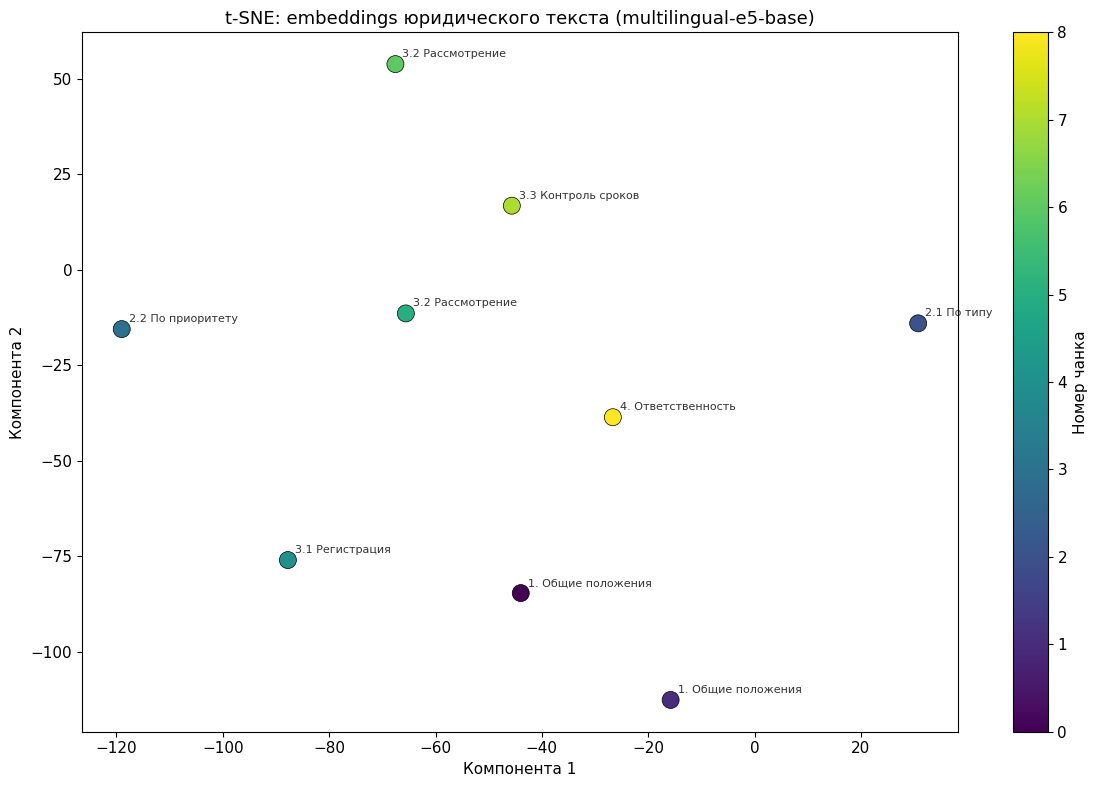


Близкие точки = семантически похожие разделы документа


In [4]:
# t-SNE: сжимаем 768 измерений в 2D для визуализации
perplexity = min(5, len(embeddings_e5) - 1)
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, max_iter=1000)
emb_2d = tsne.fit_transform(embeddings_e5)

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(
    emb_2d[:, 0], emb_2d[:, 1],
    c=range(len(emb_2d)), cmap="viridis",
    s=150, edgecolors="black", linewidth=0.5,
)

for i, chunk in enumerate(final_chunks):
    label = chunk.metadata.get(
        "Подраздел",
        chunk.metadata.get("Раздел", chunk.metadata.get("Документ", f"Чанк {i+1}")),
    )
    ax.annotate(
        label, (emb_2d[i, 0], emb_2d[i, 1]),
        fontsize=8, alpha=0.8,
        xytext=(5, 5), textcoords="offset points",
    )

plt.colorbar(scatter, label="Номер чанка")
ax.set_title("t-SNE: embeddings юридического текста (multilingual-e5-base)", fontsize=13)
ax.set_xlabel("Компонента 1")
ax.set_ylabel("Компонента 2")
plt.tight_layout()
plt.show()

print("\nБлизкие точки = семантически похожие разделы документа")

## Part 2: Сравнение Embedding моделей

Сравним три модели для русского юридического текста:

| Модель | Размерность | Описание |
|--------|------------|----------|
| `intfloat/multilingual-e5-base` | 768 | Универсальная, 100+ языков, MTEB лидер |
| `DeepPavlov/rubert-base-cased-sentence` | 768 | Специализированная на русском |
| `cointegrated/rubert-tiny2` | 312 | Компактная, быстрая, для edge/mobile |

**Критерии:** качество (cosine similarity для синонимов), скорость, размер модели.

In [5]:
models_config = [
    {
        "name": "intfloat/multilingual-e5-base",
        "prefix": "passage: ",
        "query_prefix": "query: ",
        "description": "Multilingual E5 (100+ языков)",
    },
    {
        "name": "DeepPavlov/rubert-base-cased-sentence",
        "prefix": "",
        "query_prefix": "",
        "description": "DeepPavlov RuBERT Sentence",
    },
    {
        "name": "cointegrated/rubert-tiny2",
        "prefix": "",
        "query_prefix": "",
        "description": "RuBERT Tiny2 (компактная)",
    },
]

results = {}

for cfg in models_config:
    sep = "=" * 60
    print(f"\n{sep}")
    name = cfg["name"]
    print(f"Загрузка: {name}...")

    model = SentenceTransformer(name)

    # Считаем параметры
    n_params = sum(p.numel() for p in model[0].auto_model.parameters())

    # Кодируем чанки
    start = time.time()
    embs = model.encode(
        [cfg["prefix"] + t for t in texts],
        show_progress_bar=False,
        normalize_embeddings=True,
    )
    encode_time = time.time() - start

    results[name] = {
        "embeddings": embs,
        "dim": embs.shape[1],
        "time": encode_time,
        "params": n_params,
        "description": cfg["description"],
        "query_prefix": cfg["query_prefix"],
        "prefix": cfg["prefix"],
    }

    print(f"  Размерность: {embs.shape[1]}")
    print(f"  Параметры: {n_params / 1e6:.1f}M")
    print(f"  Время кодирования {len(texts)} чанков: {encode_time:.3f} сек")

    del model
    gc.collect()

print(f"\n{'=' * 60}")
print("Все модели протестированы")


Загрузка: intfloat/multilingual-e5-base...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   1%|          | 1/199 [00:00<00:00, 13315.25it/s, Materializing param=embeddings.LayerNorm.bias]

Loading weights:   1%|          | 1/199 [00:00<00:00, 358.27it/s, Materializing param=embeddings.LayerNorm.bias]  

Loading weights:   1%|          | 2/199 [00:00<00:00, 283.79it/s, Materializing param=embeddings.LayerNorm.weight]

...

Loading weights: 100%|██████████| 55/55 [00:00<00:00, 579.43it/s, Materializing param=pooler.dense.weight]

Loading weights: 100%|██████████| 55/55 [00:00<00:00, 576.86it/s, Materializing param=pooler.dense.weight]

Loading weights: 100%|██████████| 55/55 [00:00<00:00, 570.90it/s, Materializing param=pooler.dense.weight]


BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Размерность: 312
  Параметры: 29.2M
  Время кодирования 9 чанков: 0.079 сек

Все модели протестированы


In [6]:
# Тест: семантическая близость синонимов
test_pairs = [
    ("договор купли-продажи", "соглашение о продаже"),
    ("жалоба на нарушение прав", "восстановление прав"),
    ("регистрация обращения", "прогноз погоды"),
]
pair_labels = ["синонимы (БЛИЗКО)", "связанные (средне)", "не связаны (ДАЛЕКО)"]

# Кодируем все тестовые фразы каждой моделью
all_test_texts = []
for t1, t2 in test_pairs:
    all_test_texts.extend([t1, t2])

header = f"{'Пара текстов':<55} | {'E5':>6} | {'DeepPavlov':>10} | {'Tiny2':>6}"
print(header)
print("-" * len(header))

for pair_idx, ((t1, t2), label) in enumerate(zip(test_pairs, pair_labels)):
    scores = []
    for model_name, res in results.items():
        prefix = res["query_prefix"] or res["prefix"]
        model = SentenceTransformer(model_name)
        e1 = model.encode([prefix + t1], normalize_embeddings=True)
        e2 = model.encode([prefix + t2], normalize_embeddings=True)
        sim = cosine_similarity(e1, e2)[0][0]
        scores.append(sim)
        del model
        gc.collect()

    pair_str = f'"{t1}" <-> "{t2}"'
    print(f"{pair_str:<55} | {scores[0]:>6.3f} | {scores[1]:>10.3f} | {scores[2]:>6.3f}  ({label})")

print("\nЧем ближе к 1.0 — тем более похожи тексты")

Пара текстов                                            |     E5 | DeepPavlov |  Tiny2
--------------------------------------------------------------------------------------


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   1%|          | 1/199 [00:00<00:00, 22671.91it/s, Materializing param=embeddings.LayerNorm.bias]

Loading weights:   1%|          | 1/199 [00:00<00:00, 319.13it/s, Materializing param=embeddings.LayerNorm.bias]  

Loading weights:   1%|          | 2/199 [00:00<00:00, 271.06it/s, Materializing param=embeddings.LayerNorm.weight]

...

Loading weights: 100%|██████████| 55/55 [00:00<00:00, 623.20it/s, Materializing param=pooler.dense.weight]

Loading weights: 100%|██████████| 55/55 [00:00<00:00, 615.90it/s, Materializing param=pooler.dense.weight]

Loading weights: 100%|██████████| 55/55 [00:00<00:00, 611.09it/s, Materializing param=pooler.dense.weight]


BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


"регистрация обращения" <-> "прогноз погоды"            |  0.813 |      0.668 |  0.641  (не связаны (ДАЛЕКО))

Чем ближе к 1.0 — тем более похожи тексты


In [7]:
# Сводная таблица
header = f"{'Модель':<45} | {'Dim':>5} | {'Params':>8} | {'Время':>8} | Описание"
print(header)
print("-" * len(header))

for name, res in results.items():
    print(
        f"{name:<45} | "
        f"{res['dim']:>5} | "
        f"{res['params'] / 1e6:>6.1f}M | "
        f"{res['time']:>6.3f}s | "
        f"{res['description']}"
    )

print()
print("Выводы:")
print("  - E5 — лучший баланс качества для мультиязычных задач")
print("  - DeepPavlov — хорош для чисто русских текстов")
print("  - Tiny2 — когда важна скорость (edge, мобильные устройства)")

Модель                                        |   Dim |   Params |    Время | Описание
--------------------------------------------------------------------------------------
intfloat/multilingual-e5-base                 |   768 |  278.0M |  1.612s | Multilingual E5 (100+ языков)
DeepPavlov/rubert-base-cased-sentence         |   768 |  177.9M |  5.481s | DeepPavlov RuBERT Sentence
cointegrated/rubert-tiny2                     |   312 |   29.2M |  0.079s | RuBERT Tiny2 (компактная)

Выводы:
  - E5 — лучший баланс качества для мультиязычных задач
  - DeepPavlov — хорош для чисто русских текстов
  - Tiny2 — когда важна скорость (edge, мобильные устройства)


## Part 3: Метрики схожести

Три основных способа измерить близость векторов:

| Метрика | Формула | Диапазон | Когда использовать |
|---------|---------|----------|-------------------|
| **Cosine Similarity** | cos(A,B) = (A·B)/(‖A‖·‖B‖) | [-1, 1] | Текст (99% случаев) |
| **Euclidean Distance** | ‖A-B‖₂ | [0, +∞) | Когда важна абсолютная разница |
| **Dot Product** | A·B | (-∞, +∞) | Нормализованные векторы (= cosine) |

**Для текстового RAG почти всегда используется Cosine Similarity**, потому что:
- Не зависит от длины вектора (нормализация)
- Интуитивно понятен (1 = идентичны, 0 = ортогональны, -1 = противоположны)
- Работает одинаково для разных размерностей

In [8]:
# Используем embeddings от E5 (лучшее качество)
embs = results["intfloat/multilingual-e5-base"]["embeddings"]

# Берём 3 чанка для демонстрации
i, j, k = 0, 1, len(texts) - 1
print(f"Чанк A (#{i+1}): {texts[i][:80]}...")
print(f"Чанк B (#{j+1}): {texts[j][:80]}...")
print(f"Чанк C (#{k+1}): {texts[k][:80]}...")

# Cosine Similarity
cos_ab = cosine_similarity([embs[i]], [embs[j]])[0][0]
cos_ac = cosine_similarity([embs[i]], [embs[k]])[0][0]

# Euclidean Distance
euc_ab = euclidean_distances([embs[i]], [embs[j]])[0][0]
euc_ac = euclidean_distances([embs[i]], [embs[k]])[0][0]

# Dot Product
dot_ab = float(np.dot(embs[i], embs[j]))
dot_ac = float(np.dot(embs[i], embs[k]))

header = f"{'Метрика':<22} | {'A <-> B':>10} | {'A <-> C':>10} | Ближе?"
print(f"\n{header}")
print("-" * len(header))
print(f"{'Cosine Similarity':<22} | {cos_ab:>10.4f} | {cos_ac:>10.4f} | {'A-B' if cos_ab > cos_ac else 'A-C'}")
print(f"{'Euclidean Distance':<22} | {euc_ab:>10.4f} | {euc_ac:>10.4f} | {'A-B' if euc_ab < euc_ac else 'A-C'}")
print(f"{'Dot Product':<22} | {dot_ab:>10.4f} | {dot_ac:>10.4f} | {'A-B' if dot_ab > dot_ac else 'A-C'}")

print("\nВсе три метрики согласны: чанки из одного раздела ближе друг к другу.")

Чанк A (#1): # Регламент обработки обращений граждан  
## 1. Общие положения  
Настоящий регл...
Чанк B (#2): Обращение гражданина — это направленное в организацию письменное предложение, за...
Чанк C (#9): ## 4. Ответственность  
За нарушение сроков рассмотрения обращений граждан преду...

Метрика                |    A <-> B |    A <-> C | Ближе?
---------------------------------------------------------
Cosine Similarity      |     0.8820 |     0.8811 | A-B
Euclidean Distance     |     0.4857 |     0.4876 | A-B
Dot Product            |     0.8820 |     0.8811 | A-B

Все три метрики согласны: чанки из одного раздела ближе друг к другу.


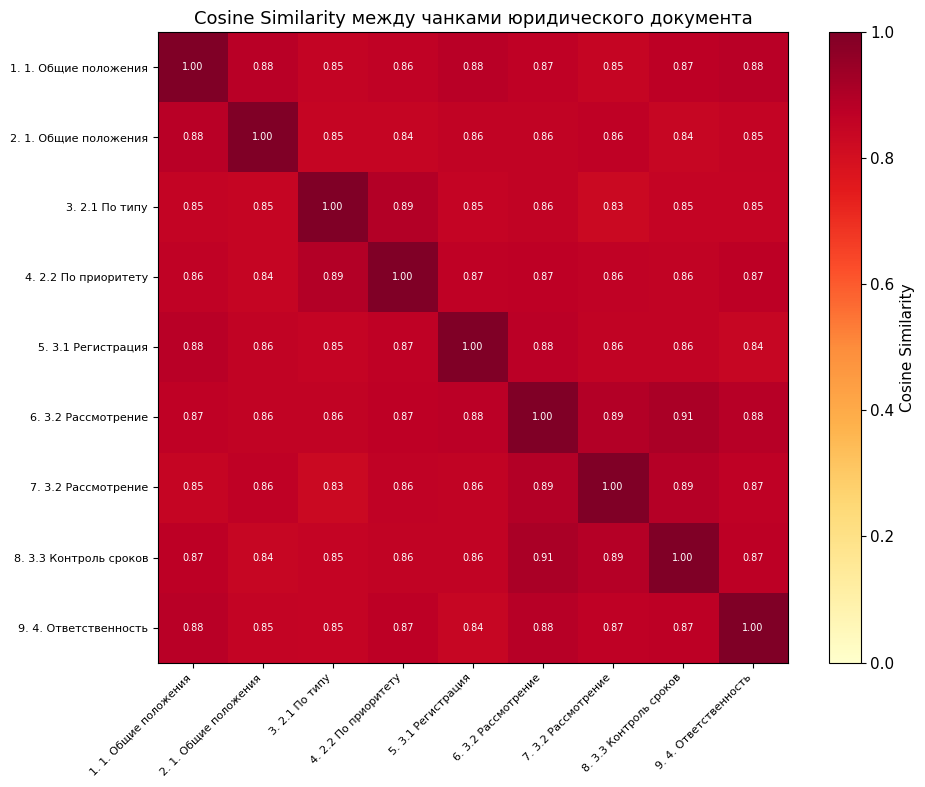

Яркие блоки на диагонали = чанки из одного раздела похожи друг на друга


In [9]:
# Heatmap: cosine similarity между всеми чанками
sim_matrix = cosine_similarity(embs)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(sim_matrix, cmap="YlOrRd", vmin=0, vmax=1)

# Подписи
labels = []
for i, chunk in enumerate(final_chunks):
    lbl = chunk.metadata.get("Подраздел",
          chunk.metadata.get("Раздел", f"Чанк {i+1}"))
    labels.append(f"{i+1}. {lbl[:20]}")

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(labels, fontsize=8)

# Значения в ячейках
for i in range(len(sim_matrix)):
    for j in range(len(sim_matrix)):
        color = "white" if sim_matrix[i][j] > 0.7 else "black"
        ax.text(j, i, f"{sim_matrix[i][j]:.2f}",
                ha="center", va="center", fontsize=7, color=color)

plt.colorbar(im, label="Cosine Similarity")
ax.set_title("Cosine Similarity между чанками юридического документа", fontsize=13)
plt.tight_layout()
plt.show()

print("Яркие блоки на диагонали = чанки из одного раздела похожи друг на друга")

## Part 4: ChromaDB — первая векторная БД

**Векторная база данных** хранит embeddings и позволяет быстро искать ближайшие векторы.

**ChromaDB** — простая, встроенная (in-process), идеальна для прототипов и небольших проектов:
- Без сервера — работает как библиотека
- Автоматические embeddings или pre-computed
- Фильтрация по метаданным
- Persistent storage (SQLite под капотом)

In [10]:
# Создаём клиент (in-memory для демо)
chroma_client = chromadb.Client()

# Удаляем коллекцию если существует (для повторного запуска)
try:
    chroma_client.delete_collection("legal_docs")
except Exception:
    pass

collection = chroma_client.create_collection(
    name="legal_docs",
    metadata={"hnsw:space": "cosine"},
)

# Используем E5 embeddings
e5_embs = results["intfloat/multilingual-e5-base"]["embeddings"]

# Добавляем чанки с embeddings и метаданными
collection.add(
    ids=[f"chunk_{i}" for i in range(len(texts))],
    documents=texts,
    embeddings=e5_embs.tolist(),
    metadatas=[
        {
            "doc_type": "регламент",
            "section": m.get("Раздел", "Общие"),
            "subsection": m.get("Подраздел", ""),
            "chunk_idx": i,
        }
        for i, m in enumerate(metadatas)
    ],
)

print(f'Коллекция "{collection.name}": {collection.count()} документов')
print("Метрика: cosine similarity")

Коллекция "legal_docs": 9 документов
Метрика: cosine similarity


In [11]:
# Поиск по запросу
query = "порядок рассмотрения жалоб"

# Кодируем запрос той же моделью (E5 с prefix 'query:')
model = SentenceTransformer("intfloat/multilingual-e5-base")
query_emb = model.encode(["query: " + query], normalize_embeddings=True)
del model
gc.collect()

# Ищем top-3
search_results = collection.query(
    query_embeddings=query_emb.tolist(),
    n_results=3,
    include=["documents", "metadatas", "distances"],
)

print(f'Запрос: "{query}"\n')
for i in range(len(search_results["ids"][0])):
    doc = search_results["documents"][0][i]
    dist = search_results["distances"][0][i]
    meta = search_results["metadatas"][0][i]
    print(f"--- Результат {i+1} (distance: {dist:.4f}) ---")
    print(f"Раздел: {meta['section']} / {meta['subsection']}")
    print(f"{doc[:200]}...\n")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   1%|          | 1/199 [00:00<00:00, 33026.02it/s, Materializing param=embeddings.LayerNorm.bias]

Loading weights:   1%|          | 1/199 [00:00<00:00, 1431.99it/s, Materializing param=embeddings.LayerNorm.bias] 

Loading weights:   1%|          | 2/199 [00:00<00:00, 325.59it/s, Materializing param=embeddings.LayerNorm.weight]

Loading weights:   1%|          | 2/199 [00:00<00:01, 185.82it/s, Materializing param=embeddings.LayerNorm.weight]

...

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 640.50it/s, Materializing param=pooler.dense.weight]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 640.50it/s, Materializing param=pooler.dense.weight]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 695.87it/s, Materializing param=pooler.dense.weight]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Запрос: "порядок рассмотрения жалоб"

--- Результат 1 (distance: 0.1548) ---
Раздел: 2. Классификация обращений / 2.2 По приоритету
### 2.2 По приоритету  
Приоритет обращения определяется автоматически на основе следующих критериев:
- **Высокий**: жалобы на нарушение прав, обращения от льготных категорий граждан, повторные обраще...

--- Результат 2 (distance: 0.1554) ---
Раздел: 1. Общие положения / 
# Регламент обработки обращений граждан  
## 1. Общие положения  
Настоящий регламент устанавливает порядок обработки обращений граждан в электронной форме. Регламент распространяется на все подраздел...

--- Результат 3 (distance: 0.1620) ---
Раздел: 1. Общие положения / 
Обращение гражданина — это направленное в организацию письменное предложение, заявление или жалоба, а также устное обращение гражданина. Каждое обращение должно быть зарегистрировано в системе в течен...



In [12]:
# Filtered search — ищем только в разделе "3. Процедура обработки"
query = "сроки рассмотрения"

model = SentenceTransformer("intfloat/multilingual-e5-base")
query_emb = model.encode(["query: " + query], normalize_embeddings=True)
del model
gc.collect()

# Без фильтра
res_all = collection.query(
    query_embeddings=query_emb.tolist(),
    n_results=3,
)

# С фильтром по разделу
res_filtered = collection.query(
    query_embeddings=query_emb.tolist(),
    n_results=3,
    where={"section": "3. Процедура обработки"},
)

print(f'Запрос: "{query}"\n')

print("БЕЗ фильтра:")
for i, (doc_id, meta) in enumerate(zip(res_all["ids"][0], res_all["metadatas"][0])):
    print(f'  {i+1}. [{doc_id}] {meta["section"]} / {meta["subsection"]}')

print(f"\nС ФИЛЬТРОМ (только раздел 3):")
for i, (doc_id, meta) in enumerate(zip(res_filtered["ids"][0], res_filtered["metadatas"][0])):
    print(f'  {i+1}. [{doc_id}] {meta["section"]} / {meta["subsection"]}')

print("\nФильтрация полезна когда пользователь уточняет контекст поиска")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   1%|          | 1/199 [00:00<00:00, 33288.13it/s, Materializing param=embeddings.LayerNorm.bias]

Loading weights:   1%|          | 1/199 [00:00<00:00, 364.98it/s, Materializing param=embeddings.LayerNorm.bias]  

Loading weights:   1%|          | 2/199 [00:00<00:00, 319.79it/s, Materializing param=embeddings.LayerNorm.weight]

Loading weights:   1%|          | 2/199 [00:00<00:00, 238.99it/s, Materializing param=embeddings.LayerNorm.weight]

...

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 802.40it/s, Materializing param=pooler.dense.weight]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 802.40it/s, Materializing param=pooler.dense.weight]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 755.14it/s, Materializing param=pooler.dense.weight]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Запрос: "сроки рассмотрения"

БЕЗ фильтра:
  1. [chunk_6] 3. Процедура обработки / 3.2 Рассмотрение
  2. [chunk_5] 3. Процедура обработки / 3.2 Рассмотрение
  3. [chunk_7] 3. Процедура обработки / 3.3 Контроль сроков

С ФИЛЬТРОМ (только раздел 3):
  1. [chunk_6] 3. Процедура обработки / 3.2 Рассмотрение
  2. [chunk_5] 3. Процедура обработки / 3.2 Рассмотрение
  3. [chunk_7] 3. Процедура обработки / 3.3 Контроль сроков

Фильтрация полезна когда пользователь уточняет контекст поиска


## Part 5: FAISS — быстрый векторный поиск

**FAISS** (Facebook AI Similarity Search) — библиотека от Meta для быстрого поиска ближайших соседей.

Три типа индексов:

| Индекс | Алгоритм | Точность | Скорость | Когда использовать |
|--------|----------|----------|----------|-------------------|
| `IndexFlatL2` | Полный перебор | 100% | Медленно | < 100K векторов |
| `IndexIVFFlat` | Кластеры + перебор | ~95-99% | Быстро | 100K - 10M векторов |
| `IndexHNSWFlat` | Граф (HNSW) | ~95-99% | Очень быстро | Любой размер, много RAM |

Для сравнения скорости сгенерируем синтетические данные (10K векторов).

In [13]:
dim = 768  # размерность E5
e5_embs_np = results["intfloat/multilingual-e5-base"]["embeddings"].astype("float32")

# 1. IndexFlatL2 — точный поиск
index_flat = faiss.IndexFlatL2(dim)
index_flat.add(e5_embs_np)

# Поиск: query embedding
model = SentenceTransformer("intfloat/multilingual-e5-base")
q = model.encode(["query: порядок рассмотрения жалоб"], normalize_embeddings=True).astype("float32")
del model
gc.collect()

distances, indices = index_flat.search(q, k=3)

print("FAISS IndexFlatL2 — точный поиск")
print(f"Индекс содержит {index_flat.ntotal} векторов\n")

print("Top-3 результата:")
for rank, (dist, idx) in enumerate(zip(distances[0], indices[0])):
    section = metadatas[idx].get("Раздел", metadatas[idx].get("Подраздел", ""))
    print(f"  {rank+1}. Чанк {idx+1} (L2={dist:.4f}) | {section}")
    print(f"     {texts[idx][:100]}...\n")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   1%|          | 1/199 [00:00<00:00, 18641.35it/s, Materializing param=embeddings.LayerNorm.bias]

Loading weights:   1%|          | 1/199 [00:00<00:00, 627.61it/s, Materializing param=embeddings.LayerNorm.bias]  

Loading weights:   1%|          | 2/199 [00:00<00:00, 688.78it/s, Materializing param=embeddings.LayerNorm.weight]

Loading weights:   1%|          | 2/199 [00:00<00:00, 436.66it/s, Materializing param=embeddings.LayerNorm.weight]

...

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 810.44it/s, Materializing param=pooler.dense.weight]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 810.44it/s, Materializing param=pooler.dense.weight]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 810.01it/s, Materializing param=pooler.dense.weight]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FAISS IndexFlatL2 — точный поиск
Индекс содержит 9 векторов

Top-3 результата:
  1. Чанк 4 (L2=0.3097) | 2. Классификация обращений
     ### 2.2 По приоритету  
Приоритет обращения определяется автоматически на основе следующих критериев...

  2. Чанк 1 (L2=0.3107) | 1. Общие положения
     # Регламент обработки обращений граждан  
## 1. Общие положения  
Настоящий регламент устанавливает ...

  3. Чанк 2 (L2=0.3239) | 1. Общие положения
     Обращение гражданина — это направленное в организацию письменное предложение, заявление или жалоба, ...



In [14]:
# Бенчмарк: сравнение индексов на 10K синтетических векторов
n_vectors = 10_000
dim = 768
np.random.seed(42)

# Генерируем синтетические embeddings (нормализованные)
synthetic_data = np.random.randn(n_vectors, dim).astype("float32")
faiss.normalize_L2(synthetic_data)

n_queries = 100
queries = np.random.randn(n_queries, dim).astype("float32")
faiss.normalize_L2(queries)

benchmark = {}

# 1. IndexFlatL2
idx_flat = faiss.IndexFlatL2(dim)
idx_flat.add(synthetic_data)
start = time.time()
d_flat, i_flat = idx_flat.search(queries, k=5)
benchmark["IndexFlatL2"] = {
    "time": (time.time() - start) / n_queries * 1000,
    "recall": 1.0,
}

# 2. IndexIVFFlat (кластерный)
nlist = 50
quantizer = faiss.IndexFlatL2(dim)
idx_ivf = faiss.IndexIVFFlat(quantizer, dim, nlist)
idx_ivf.train(synthetic_data)
idx_ivf.add(synthetic_data)
idx_ivf.nprobe = 5
start = time.time()
d_ivf, i_ivf = idx_ivf.search(queries, k=5)
ivf_time = (time.time() - start) / n_queries * 1000
recall_ivf = np.mean([len(set(i_flat[j]) & set(i_ivf[j])) / 5 for j in range(n_queries)])
benchmark["IndexIVFFlat"] = {"time": ivf_time, "recall": recall_ivf}

# 3. IndexHNSWFlat (граф)
idx_hnsw = faiss.IndexHNSWFlat(dim, 32)
idx_hnsw.add(synthetic_data)
idx_hnsw.hnsw.efSearch = 64
start = time.time()
d_hnsw, i_hnsw = idx_hnsw.search(queries, k=5)
hnsw_time = (time.time() - start) / n_queries * 1000
recall_hnsw = np.mean([len(set(i_flat[j]) & set(i_hnsw[j])) / 5 for j in range(n_queries)])
benchmark["IndexHNSWFlat"] = {"time": hnsw_time, "recall": recall_hnsw}

# Результаты
print(f"Бенчмарк: {n_vectors:,} векторов, {dim}-dim, top-5, среднее по {n_queries} запросам\n")
header = f"{'Индекс':<20} | {'Время (мс/запрос)':>18} | {'Recall@5':>10} | Примечание"
print(header)
print("-" * len(header))
for name, res in benchmark.items():
    note = "Точный" if res["recall"] == 1.0 else "Приближённый"
    print(f"{name:<20} | {res['time']:>18.3f} | {res['recall']:>10.3f} | {note}")

print("\nIVF и HNSW жертвуют 1-5% точности ради значительного ускорения.")
print("На миллионах векторов разница в скорости будет ещё драматичнее.")

Бенчмарк: 10,000 векторов, 768-dim, top-5, среднее по 100 запросам

Индекс               |  Время (мс/запрос) |   Recall@5 | Примечание
-------------------------------------------------------------------
IndexFlatL2          |              0.823 |      1.000 | Точный
IndexIVFFlat         |              0.229 |      0.186 | Приближённый
IndexHNSWFlat        |              0.529 |      0.506 | Приближённый

IVF и HNSW жертвуют 1-5% точности ради значительного ускорения.
На миллионах векторов разница в скорости будет ещё драматичнее.


## Part 6: Полный Retrieval Pipeline

Собираем всё вместе: **документ → chunking → embedding → vector store → search → evaluation**

Это скелет RAG-системы. В Модуле 3 добавим reranking и hybrid search.

In [15]:
class RetrievalPipeline:
    "Полный retrieval pipeline: text -> chunks -> embeddings -> search."

    def __init__(self, model_name="intfloat/multilingual-e5-base", chunk_size=400, chunk_overlap=50):
        self.model_name = model_name
        self.chunk_size = chunk_size
        self.chunk_overlap = chunk_overlap
        self.model = SentenceTransformer(model_name)
        self.chroma_client = chromadb.Client()
        self.collection = None
        self.chunks = []

    def ingest(self, document, collection_name="pipeline_docs"):
        "Загрузить документ: chunking -> embedding -> store."
        # Chunking
        md_splitter = MarkdownHeaderTextSplitter(
            headers_to_split_on=[
                ("#", "Документ"),
                ("##", "Раздел"),
                ("###", "Подраздел"),
            ],
            strip_headers=False,
        )
        header_chunks = md_splitter.split_text(document)

        recursive_splitter = RecursiveCharacterTextSplitter(
            chunk_size=self.chunk_size,
            chunk_overlap=self.chunk_overlap,
        )

        self.chunks = []
        for chunk in header_chunks:
            if len(chunk.page_content) > self.chunk_size:
                sub_chunks = recursive_splitter.create_documents(
                    [chunk.page_content], metadatas=[chunk.metadata]
                )
                self.chunks.extend(sub_chunks)
            else:
                self.chunks.append(chunk)

        chunk_texts = [c.page_content for c in self.chunks]

        # Embedding
        embeddings = self.model.encode(
            ["passage: " + t for t in chunk_texts],
            normalize_embeddings=True,
            show_progress_bar=True,
        )

        # Store in ChromaDB
        try:
            self.chroma_client.delete_collection(collection_name)
        except Exception:
            pass

        self.collection = self.chroma_client.create_collection(
            name=collection_name,
            metadata={"hnsw:space": "cosine"},
        )

        self.collection.add(
            ids=[f"chunk_{i}" for i in range(len(chunk_texts))],
            documents=chunk_texts,
            embeddings=embeddings.tolist(),
            metadatas=[
                {
                    "section": m.get("Раздел", ""),
                    "subsection": m.get("Подраздел", ""),
                }
                for m in [c.metadata for c in self.chunks]
            ],
        )

        print(f'Загружено {len(self.chunks)} чанков в коллекцию "{collection_name}"')
        return self

    def search(self, query, top_k=5):
        "Поиск по запросу."
        query_emb = self.model.encode(
            ["query: " + query],
            normalize_embeddings=True,
        )
        results = self.collection.query(
            query_embeddings=query_emb.tolist(),
            n_results=top_k,
            include=["documents", "metadatas", "distances"],
        )
        return results


# Создаём pipeline и загружаем документ
pipeline = RetrievalPipeline()
pipeline.ingest(LEGAL_DOC)

# Тестовые запросы
test_queries = [
    "порядок рассмотрения жалоб",
    "сроки обработки обращений граждан",
    "как зарегистрировать обращение",
    "ответственность за нарушение сроков",
    "приоритет обращений льготных категорий",
]

for query in test_queries:
    sep = "=" * 60
    print(f"\n{sep}")
    print(f'Запрос: "{query}"\n')
    res = pipeline.search(query, top_k=3)
    for i in range(len(res["ids"][0])):
        dist = res["distances"][0][i]
        meta = res["metadatas"][0][i]
        doc = res["documents"][0][i]
        section = meta["section"]
        print(f"  {i+1}. (dist={dist:.4f}) [{section}] {doc[:120]}...")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   1%|          | 1/199 [00:00<00:00, 27413.75it/s, Materializing param=embeddings.LayerNorm.bias]

Loading weights:   1%|          | 1/199 [00:00<00:00, 262.23it/s, Materializing param=embeddings.LayerNorm.bias]  

Loading weights:   1%|          | 2/199 [00:00<00:00, 345.98it/s, Materializing param=embeddings.LayerNorm.weight]

Loading weights:   1%|          | 2/199 [00:00<00:00, 241.45it/s, Materializing param=embeddings.LayerNorm.weight]

...

Batches: 100%|██████████| 1/1 [00:01<00:00,  1.54s/it]

Batches: 100%|██████████| 1/1 [00:01<00:00,  1.55s/it]

Загружено 9 чанков в коллекцию "pipeline_docs"

Запрос: "порядок рассмотрения жалоб"

  1. (dist=0.1548) [2. Классификация обращений] ### 2.2 По приоритету  
Приоритет обращения определяется автоматически на основе следующих критериев:
- **Высокий**: жал...
  2. (dist=0.1554) [1. Общие положения] # Регламент обработки обращений граждан  
## 1. Общие положения  
Настоящий регламент устанавливает порядок обработки об...
  3. (dist=0.1620) [1. Общие положения] Обращение гражданина — это направленное в организацию письменное предложение, заявление или жалоба, а также устное обращ...

Запрос: "сроки обработки обращений граждан"

  1. (dist=0.1335) [1. Общие положения] Обращение гражданина — это направленное в организацию письменное предложение, заявление или жалоба, а также устное обращ...
  2. (dist=0.1354) [3. Процедура обработки] Срок рассмотрения обращения не должен превышать 30 календарных дней с момента регистрации. В исключительных случаях срок...
  3. (dist=0.1422) [1. Общие положен

  1. (dist=0.1311) [1. Общие положения] Обращение гражданина — это направленное в организацию письменное предложение, заявление или жалоба, а также устное обращ...
  2. (dist=0.1475) [3. Процедура обработки] ## 3. Процедура обработки  
### 3.1 Регистрация  
При поступлении обращения оператор выполняет следующие действия:
1. Пр...
  3. (dist=0.1611) [3. Процедура обработки] Срок рассмотрения обращения не должен превышать 30 календарных дней с момента регистрации. В исключительных случаях срок...

Запрос: "ответственность за нарушение сроков"

  1. (dist=0.1206) [4. Ответственность] ## 4. Ответственность  
За нарушение сроков рассмотрения обращений граждан предусмотрена дисциплинарная ответственность ...
  2. (dist=0.1773) [3. Процедура обработки] ### 3.3 Контроль сроков  
Система автоматически отслеживает сроки обработки обращений:
- За 5 дней до истечения срока — ...
  3. (dist=0.1837) [3. Процедура обработки] ### 3.2 Рассмотрение  
Ответственный исполнитель обязан:
- Изучить суть обра

  1. (dist=0.1118) [2. Классификация обращений] ### 2.2 По приоритету  
Приоритет обращения определяется автоматически на основе следующих критериев:
- **Высокий**: жал...
  2. (dist=0.1714) [2. Классификация обращений] ## 2. Классификация обращений  
### 2.1 По типу  
Обращения классифицируются следующим образом:
- **Предложение** — реко...
  3. (dist=0.1827) [1. Общие положения] # Регламент обработки обращений граждан  
## 1. Общие положения  
Настоящий регламент устанавливает порядок обработки об...


In [16]:
# Evaluation: Recall@K и Precision@K
# Ground truth: для каждого запроса — какие чанки релевантны

chunk_texts = [c.page_content for c in pipeline.chunks]

ground_truth = {
    "порядок рассмотрения жалоб": [
        i for i, t in enumerate(chunk_texts)
        if "жалоб" in t.lower() or "рассмотрен" in t.lower()
    ],
    "сроки обработки обращений граждан": [
        i for i, t in enumerate(chunk_texts)
        if "срок" in t.lower() or "дней" in t.lower() or "календарн" in t.lower()
    ],
    "как зарегистрировать обращение": [
        i for i, t in enumerate(chunk_texts)
        if "регистрац" in t.lower() or "регистрационн" in t.lower()
    ],
    "ответственность за нарушение сроков": [
        i for i, t in enumerate(chunk_texts)
        if "ответственность" in t.lower() or "дисциплинарн" in t.lower()
    ],
    "приоритет обращений льготных категорий": [
        i for i, t in enumerate(chunk_texts)
        if "приоритет" in t.lower() or "льготн" in t.lower()
    ],
}

header = f"{'Запрос':<45} | {'Recall@3':>10} | {'Precision@3':>12} | Релевантных"
print(header)
print("-" * len(header))

recalls = []
precisions = []

for query, relevant_ids in ground_truth.items():
    if not relevant_ids:
        continue

    res = pipeline.search(query, top_k=3)
    retrieved_ids = [int(doc_id.split("_")[1]) for doc_id in res["ids"][0]]

    hits = len(set(retrieved_ids) & set(relevant_ids))
    recall = hits / len(relevant_ids) if relevant_ids else 0
    precision = hits / len(retrieved_ids) if retrieved_ids else 0

    recalls.append(recall)
    precisions.append(precision)

    print(f"{query:<45} | {recall:>10.2f} | {precision:>12.2f} | {len(relevant_ids)}")

print(f"\n{'=' * len(header)}")
avg_r = np.mean(recalls) if recalls else 0
avg_p = np.mean(precisions) if precisions else 0
print(f"{'Среднее:':<45} | {avg_r:>10.2f} | {avg_p:>12.2f}")

print("\nRecall — доля найденных релевантных документов из всех релевантных")
print("Precision — доля релевантных среди найденных")

Запрос                                        |   Recall@3 |  Precision@3 | Релевантных
---------------------------------------------------------------------------------------
порядок рассмотрения жалоб                    |       0.33 |         0.67 | 6


сроки обработки обращений граждан             |       0.25 |         0.33 | 4


как зарегистрировать обращение                |       1.00 |         0.67 | 2
ответственность за нарушение сроков           |       1.00 |         0.33 | 1


приоритет обращений льготных категорий        |       0.50 |         0.33 | 2

Среднее:                                      |       0.62 |         0.47

Recall — доля найденных релевантных документов из всех релевантных
Precision — доля релевантных среди найденных


## Part 7: Практическое задание

### Задание

1. **Эксперимент с chunk_size:** измените `chunk_size` в pipeline на 200 и 600. Как это влияет на Recall@3 и Precision@3?

2. **Другая модель:** замените E5 на `DeepPavlov/rubert-base-cased-sentence` в pipeline. Изменится ли качество поиска?

3. **Свой документ:** загрузите другой юридический текст и проверьте pipeline.

---

### Выводы модуля

| Что узнали | Ключевой вывод |
|-----------|---------------|
| Embeddings | Текст → вектор. Семантически близкие тексты → близкие векторы |
| Модели | E5 — лучший баланс. DeepPavlov — специализация на RU. Tiny2 — скорость |
| Метрики | Cosine similarity — стандарт для текстового RAG |
| ChromaDB | Простая, с фильтрацией по метаданным, идеальна для прототипов |
| FAISS | Быстрый поиск, разные индексы для разных масштабов |
| Pipeline | document → chunks → embeddings → vector store → similarity search |

### Что дальше (Модуль 3)

- **Hybrid Search:** dense (embeddings) + sparse (BM25) retrieval
- **Reranking:** cross-encoder для переранжирования результатов
- **Advanced retrieval:** HyDE, multi-query, parent document retriever